# IGRO - notebook para figuras e tabelas do artigo

Este notebook foi pensado para apoiar a elaboracao das tabelas e graficos sugeridos em `10_publicacao/submissao/artigo_igro_v2_critica_aplicada.md` a partir dos dados em `02_dados/processed`.

Escopo:
- ler os arquivos processados, mesmo quando vierem encapsulados em HTML/JavaScript;
- montar as tabelas centrais do artigo;
- gerar os graficos sugeridos nas secoes de resultados;
- acrescentar analises extras uteis para robustez e transparencia metodologica.

Assuncoes operacionais usadas aqui:
- `rdp` foi tratado como `PMA` (percentual de manifestacoes em atraso);
- `tr` foi tratado como `RP` (resolutividade percebida);
- `ri` foi tratado como `%RI`;
- `nps` foi tratado como `NR` em escala NPS;
- as faixas de risco foram inferidas a partir do HTML renderizado do projeto: `Controlado >= 90`, `Atencao >= 70`, `Elevado >= 50`, `Critico < 50`.

Observacao importante: a base processada atualmente traz `52` orgaos, enquanto o artigo menciona `51`. O notebook destaca essa divergencia para revisao editorial/metodologica.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None

from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "02_dados").exists():
            return candidate
    raise FileNotFoundError("Nao foi possivel localizar a raiz do repositorio.")

ROOT = find_repo_root()
DATA_DIR = ROOT / "02_dados" / "processed"
OUTPUT_DIR = ROOT / "09_resultados" / "artigo_igro_figuras_tabelas"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT, DATA_DIR, OUTPUT_DIR

(WindowsPath('C:/Users/andrei.lima/OneDrive/Claude-Work/Projects/igro'),
 WindowsPath('C:/Users/andrei.lima/OneDrive/Claude-Work/Projects/igro/02_dados/processed'),
 WindowsPath('C:/Users/andrei.lima/OneDrive/Claude-Work/Projects/igro/09_resultados/artigo_igro_figuras_tabelas'))

In [2]:
def parse_js_payload(text: str, anchor: str = "const D=") -> list[dict]:
    pattern = rf"{re.escape(anchor)}(\[.*?\]);const"
    match = re.search(pattern, text, flags=re.DOTALL)
    if not match:
        raise ValueError("Payload JavaScript nao encontrado no arquivo.")
    payload = match.group(1)
    payload = re.sub(r"([\{,])(\s*)([A-Za-z_][A-Za-z0-9_]*)\s*:", r'\1"\3":', payload)
    payload = payload.replace("'", '"')
    return json.loads(payload)

def load_processed_export(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8", errors="replace")
    if "const D=" in text:
        return pd.DataFrame(parse_js_payload(text, anchor="const D="))
    return pd.read_csv(path)

def classify_risk(igro_pct: float) -> str:
    if pd.isna(igro_pct):
        return "Sem dado"
    if igro_pct >= 90:
        return "Controlado"
    if igro_pct >= 70:
        return "Atencao"
    if igro_pct >= 50:
        return "Elevado"
    return "Critico"

def save_fig(fig: plt.Figure, name: str) -> None:
    fig.savefig(OUTPUT_DIR / name, dpi=200, bbox_inches="tight")

def save_table(df: pd.DataFrame, name: str) -> None:
    df.to_csv(OUTPUT_DIR / name, index=False, encoding="utf-8-sig")

df = load_processed_export(DATA_DIR / "geral.csv")

rename_map = {
    "sigla": "orgao",
    "classe": "classe_operacional",
    "manifestacoes": "manifestacoes",
    "pesquisas": "pesquisas",
    "tmr": "tmr_dias",
    "rdp": "pma",
    "tr": "rp",
    "ri": "ri",
    "nps": "nr_nps",
    "igro": "igro",
    "sub_t": "sub_tempestividade",
    "sub_q": "sub_qualidade",
    "flag_amostra": "flag_amostra"
}
df = df.rename(columns=rename_map)

for col in ["pma", "rp", "ri", "igro", "sub_tempestividade", "sub_qualidade"]:
    df[f"{col}_pct"] = df[col] * 100

df["classe_operacional"] = df["classe_operacional"].astype(str)
df["faixa_risco"] = df["igro_pct"].apply(classify_risk)
df["amostra_insuficiente"] = df["flag_amostra"].astype(int).eq(1)

score_cols = ["score_rdp", "score_tmr", "score_tr", "score_ri", "score_nr"]
score_cols_pct = []
for col in score_cols:
    if col in df.columns:
        df[f"{col}_pct"] = df[col] * 100
        score_cols_pct.append(f"{col}_pct")

df = df.sort_values("igro_pct", ascending=False).reset_index(drop=True)
df.head()

,orgao,tipo,grupo,classe_operacional,manifestacoes,finalizadas,abertas,pesquisas,tmr_dias,pma,rp,ri,nota,nr_nps,promotores,neutros,detratores,score_rdp,score_tmr,score_tr,score_ri,score_nr,sub_tempestividade,sub_qualidade,igro,flag_amostra,pma_pct,rp_pct,ri_pct,igro_pct,sub_tempestividade_pct,sub_qualidade_pct,faixa_risco,amostra_insuficiente,score_rdp_pct,score_tmr_pct,score_tr_pct,score_ri_pct,score_nr_pct
0,GOINFRA,Setorial,A,3,2109,2109,0,501,4.4600,0.0005,0.7345,0.0171,9.0500,73.8500,0.8363,0.0659,0.0978,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0,0.0500,73.4500,1.7100,100.0000,100.0000,100.0000,Controlado,False,100.0000,100.0000,100.0000,100.0000,100.0000
1,SEMAD,Setorial,A,2,6126,6126,0,429,3.2100,0.0024,0.6772,0.0011,8.9100,67.6000,0.7972,0.0816,0.1212,1.0000,1.0000,0.8858,1.0000,1.0000,1.0000,0.9543,0.9769,0,0.2400,67.7200,0.1100,97.6900,100.0000,95.4300,Controlado,False,100.0000,100.0000,88.5800,100.0000,100.0000
2,METROBUS,Adjunta,B,4,190,190,0,23,3.7700,0.0000,0.6522,0.0053,8.0400,39.1300,0.6522,0.0870,0.2609,1.0000,1.0000,0.7609,1.0000,1.0000,1.0000,0.9043,0.9510,0,0.0000,65.2200,0.5300,95.1000,100.0000,90.4300,Controlado,False,100.0000,100.0000,76.0900,100.0000,100.0000
3,DGPP,Adjunta,B,3,1089,1089,0,60,4.1700,0.0000,0.6500,0.0092,8.5200,56.6700,0.7500,0.0667,0.1833,1.0000,1.0000,0.7500,1.0000,1.0000,1.0000,0.9000,0.9487,0,0.0000,65.0000,0.9200,94.8700,100.0000,90.0000,Controlado,False,100.0000,100.0000,75.0000,100.0000,100.0000
4,GOIÁSFOMENTO,Adjunta,B,5,119,119,0,17,5.8700,0.0000,0.7647,0.0168,8.0000,52.9400,0.7647,0.0000,0.2353,1.0000,0.8269,1.0000,1.0000,1.0000,0.8961,1.0000,0.9466,0,0.0000,76.4700,1.6800,94.6600,89.6100,100.0000,Controlado,False,100.0000,82.6900,100.0000,100.0000,100.0000


## 1. Checagem inicial da base

Esta secao ajuda a conferir rapidamente se o conjunto usado no artigo bate com o export processado atual.

In [3]:
resumo_base = pd.DataFrame(
    {
        "metrica": [
            "orgaos na base",
            "manifestacoes totais",
            "pesquisas totais",
            "orgaos com amostra insuficiente",
            "orgaos com IGRO zero",
            "IGRO medio (%)"
        ],
        "valor": [
            len(df),
            int(df["manifestacoes"].sum()),
            int(df["pesquisas"].sum()),
            int(df["amostra_insuficiente"].sum()),
            int(df["igro_pct"].eq(0).sum()),
            round(df["igro_pct"].mean(), 1)
        ]
    }
)
display(resumo_base)

if len(df) != 51:
    print(f"ALERTA: a base processada atual contem {len(df)} orgaos, enquanto o artigo menciona 51.")
    print("Sugestao: revisar se ha algum orgao que deve ser excluido editorialmente antes da versao final.")

,metrica,valor
0,orgaos na base,52.0000
1,manifestacoes totais,"112,639.0000"
2,pesquisas totais,"10,854.0000"
3,orgaos com amostra insuficiente,3.0000
4,orgaos com IGRO zero,10.0000
5,IGRO medio (%),52.9000


ALERTA: a base processada atual contem 52 orgaos, enquanto o artigo menciona 51.
Sugestao: revisar se ha algum orgao que deve ser excluido editorialmente antes da versao final.


## 2. Tabela 4 - distribuicao operacional da rede

Corresponde diretamente a `Tabela 4 - Distribuicao operacional da rede` sugerida no artigo.

In [4]:
tabela_classes = (
    df.groupby("classe_operacional", as_index=False)
      .agg(
          orgaos=("orgao", "count"),
          total_manifestacoes=("manifestacoes", "sum"),
          igro_medio_pct=("igro_pct", "mean"),
          pesquisas=("pesquisas", "sum")
      )
      .sort_values("classe_operacional")
)
tabela_classes["igro_medio_pct"] = tabela_classes["igro_medio_pct"].round(1)
display(tabela_classes)
save_table(tabela_classes, "tabela_4_distribuicao_operacional.csv")

,classe_operacional,orgaos,total_manifestacoes,igro_medio_pct,pesquisas
0,1,3,47821,64.6000,5318
1,2,7,45909,65.7000,3432
2,3,7,12735,73.1000,1311
3,4,15,5355,54.8000,666
4,5,20,819,38.3000,127


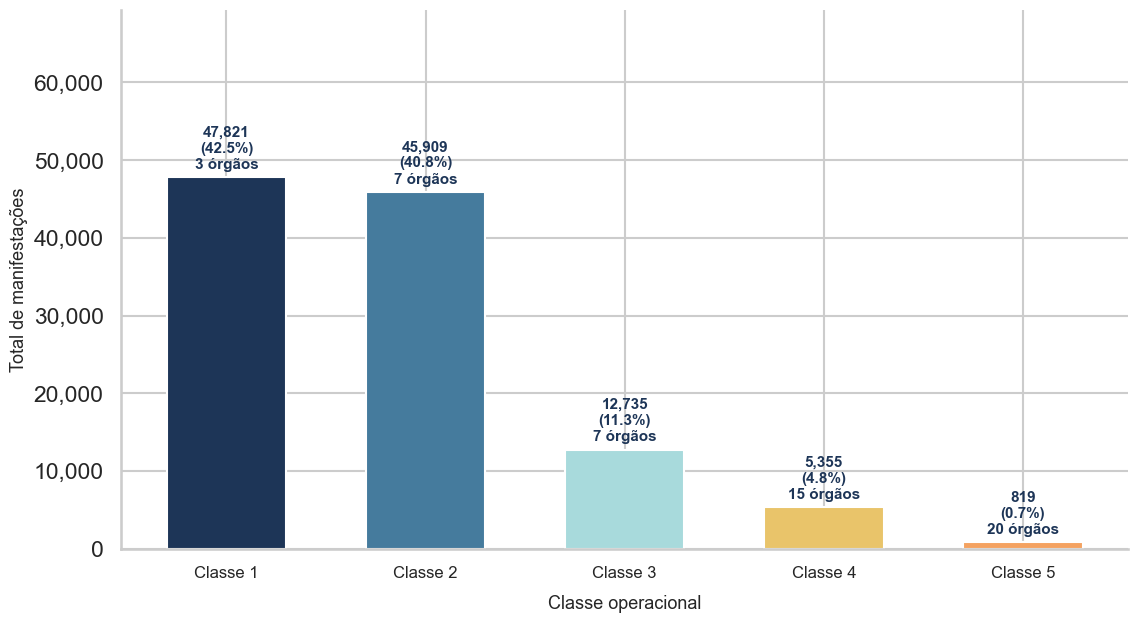

Total de manifestações: 112,639


In [5]:
# Grafico 1 - Distribuicao de manifestacoes por classe operacional
total_manifest = tabela_classes["total_manifestacoes"].sum()
tabela_classes["pct"] = tabela_classes["total_manifestacoes"] / total_manifest * 100

cores_cl = ["#1D3557", "#457B9D", "#A8DADC", "#E9C46A", "#F4A261"]
labels_x = [f"Classe {c}" for c in tabela_classes["classe_operacional"]]

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.bar(
    labels_x,
    tabela_classes["total_manifestacoes"],
    color=cores_cl,
    edgecolor="white",
    linewidth=1.5,
    width=0.6
)

max_val = tabela_classes["total_manifestacoes"].max()
ax.set_ylim(0, max_val * 1.45)

for bar, (_, row) in zip(bars, tabela_classes.iterrows()):
    h = bar.get_height()
    n_orgaos = int(row["orgaos"])
    label = f"{h:,.0f}\n({row['pct']:.1f}%)\n{n_orgaos} órgão{'s' if n_orgaos > 1 else ''}"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max_val * 0.015,
        label,
        ha="center", va="bottom", fontsize=11, fontweight="bold", color="#1D3557"
    )

ax.set_xlabel("Classe operacional", labelpad=10)
ax.set_ylabel("Total de manifestações")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.tick_params(axis="x", labelsize=12)
sns.despine(left=False, bottom=False)

save_fig(fig, "grafico_1_distribuicao_manifestacoes_por_classe.png")
plt.show()
print(f"Total de manifestações: {total_manifest:,.0f}")

## 3. Graficos centrais do artigo

Abaixo estao as sugestoes que espelham as chamadas do texto: Grafico 1 a Grafico 6, alem do heatmap dos KRIs.

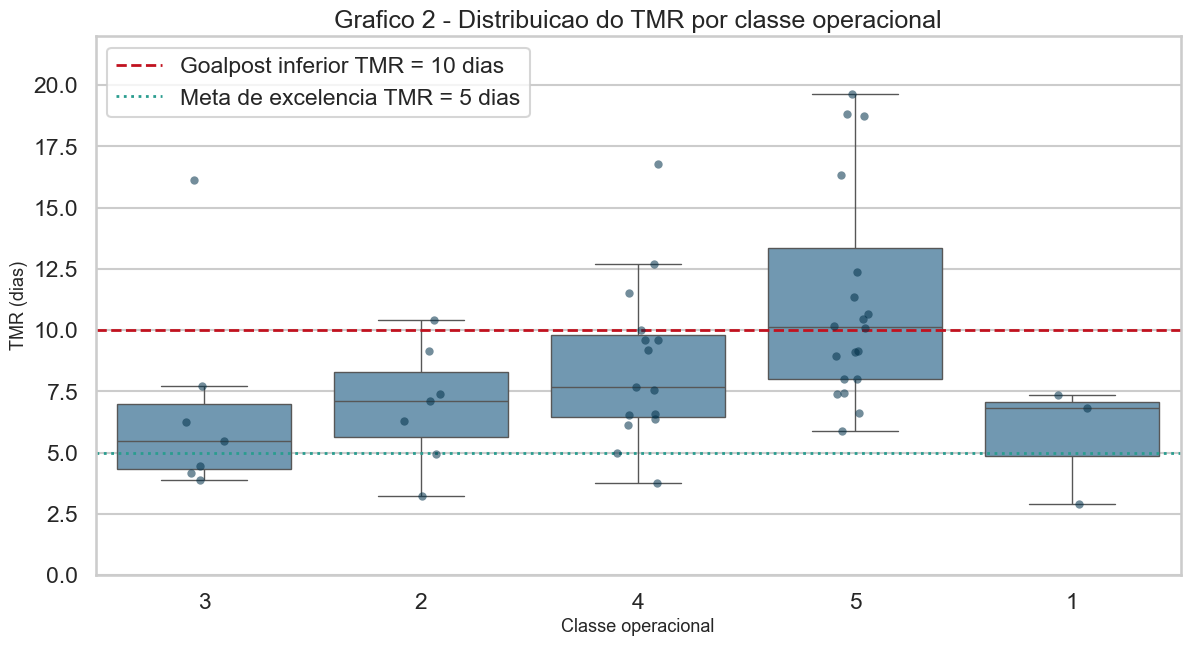

In [6]:
# Grafico 2 - TMR por classe operacional (sem outliers para melhor visualizacao)
fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df, x="classe_operacional", y="tmr_dias", color="#669BBC", ax=ax, showfliers=False)
sns.stripplot(data=df, x="classe_operacional", y="tmr_dias", color="#003049", alpha=0.55, size=6, ax=ax)
ax.axhline(10, color="#C1121F", linestyle="--", linewidth=2, label="Goalpost inferior TMR = 10 dias")
ax.axhline(5, color="#2A9D8F", linestyle=":", linewidth=2, label="Meta de excelencia TMR = 5 dias")
ax.set_title("Grafico 2 - Distribuicao do TMR por classe operacional")
ax.set_xlabel("Classe operacional")
ax.set_ylabel("TMR (dias)")
ax.set_ylim(0, 22)
ax.legend(loc="upper left")
save_fig(fig, "grafico_2_boxplot_tmr_por_classe.png")
plt.show()

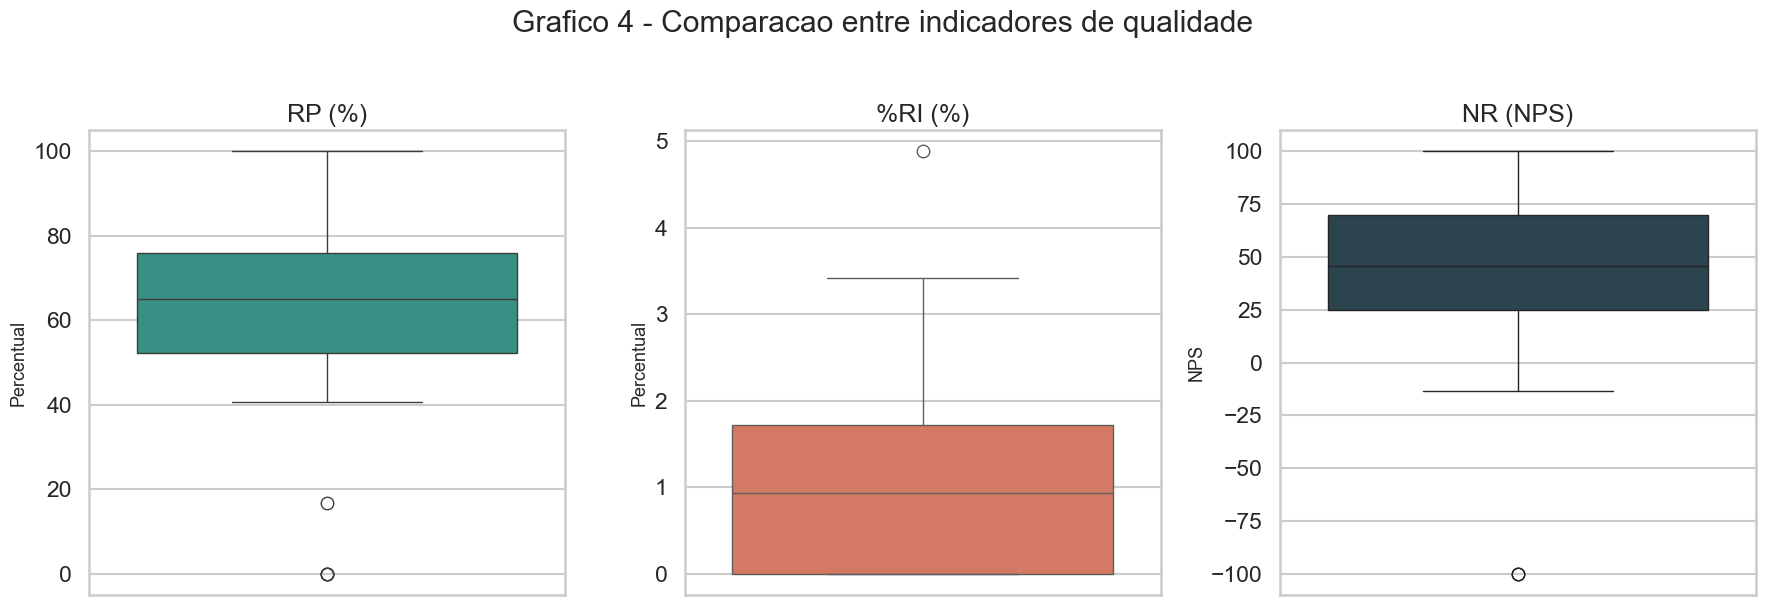

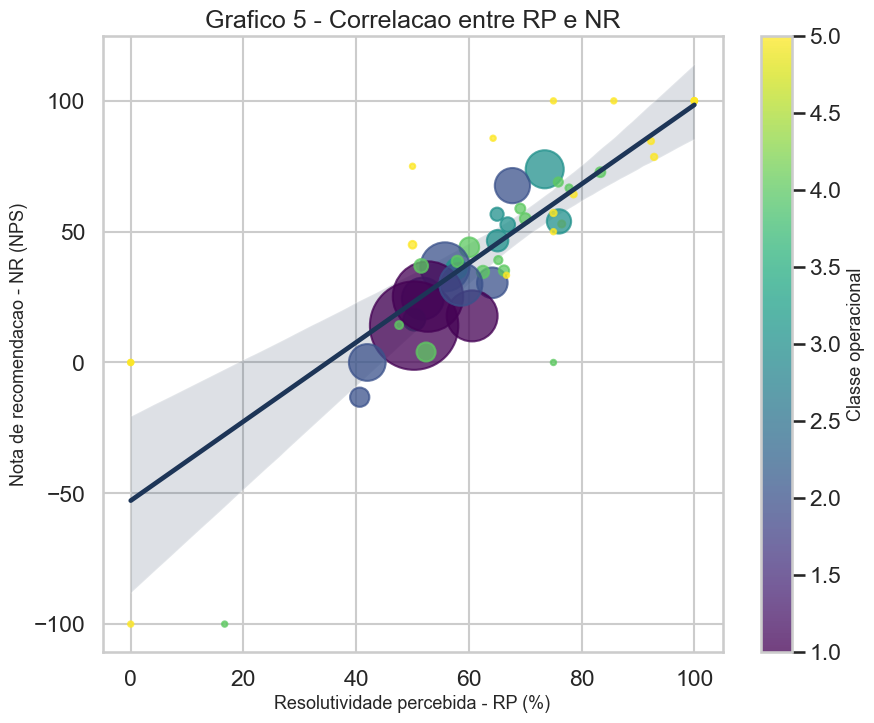

In [7]:
# Grafico 4 - comparacao entre indicadores de qualidade
quality_long = pd.DataFrame(
    {
        "indicador": np.repeat(["RP (%)", "%RI (%)", "NR (NPS)"], len(df)),
        "valor": np.concatenate([df["rp_pct"].to_numpy(), df["ri_pct"].to_numpy(), df["nr_nps"].to_numpy()])
    }
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.boxplot(data=df, y="rp_pct", color="#2A9D8F", ax=axes[0])
axes[0].set_title("RP (%)")
axes[0].set_ylabel("Percentual")

sns.boxplot(data=df, y="ri_pct", color="#E76F51", ax=axes[1])
axes[1].set_title("%RI (%)")
axes[1].set_ylabel("Percentual")

sns.boxplot(data=df, y="nr_nps", color="#264653", ax=axes[2])
axes[2].set_title("NR (NPS)")
axes[2].set_ylabel("NPS")

fig.suptitle("Grafico 4 - Comparacao entre indicadores de qualidade", y=1.02)
fig.tight_layout()
save_fig(fig, "grafico_4_comparacao_indicadores_qualidade.png")
plt.show()

# Grafico 5 - correlacao entre RP e NR
fig, ax = plt.subplots(figsize=(10, 8))
sns.regplot(data=df, x="rp_pct", y="nr_nps", scatter=False, color="#1D3557", ax=ax)
scatter = ax.scatter(df["rp_pct"], df["nr_nps"], s=np.maximum(df["pesquisas"], 10) * 1.5, c=df["classe_operacional"].astype(int), cmap="viridis", alpha=0.75)
ax.set_title("Grafico 5 - Correlacao entre RP e NR")
ax.set_xlabel("Resolutividade percebida - RP (%)")
ax.set_ylabel("Nota de recomendacao - NR (NPS)")
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Classe operacional")

if spearmanr is not None:
    coef, p_value = spearmanr(df["rp_pct"], df["nr_nps"])
    ax.text(0.02, 0.98, f"Spearman = {coef:.3f}\np-valor = {p_value:.4g}", transform=ax.transAxes, ha="left", va="top", bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "#999"})

save_fig(fig, "grafico_5_correlacao_rp_nr.png")
plt.show()

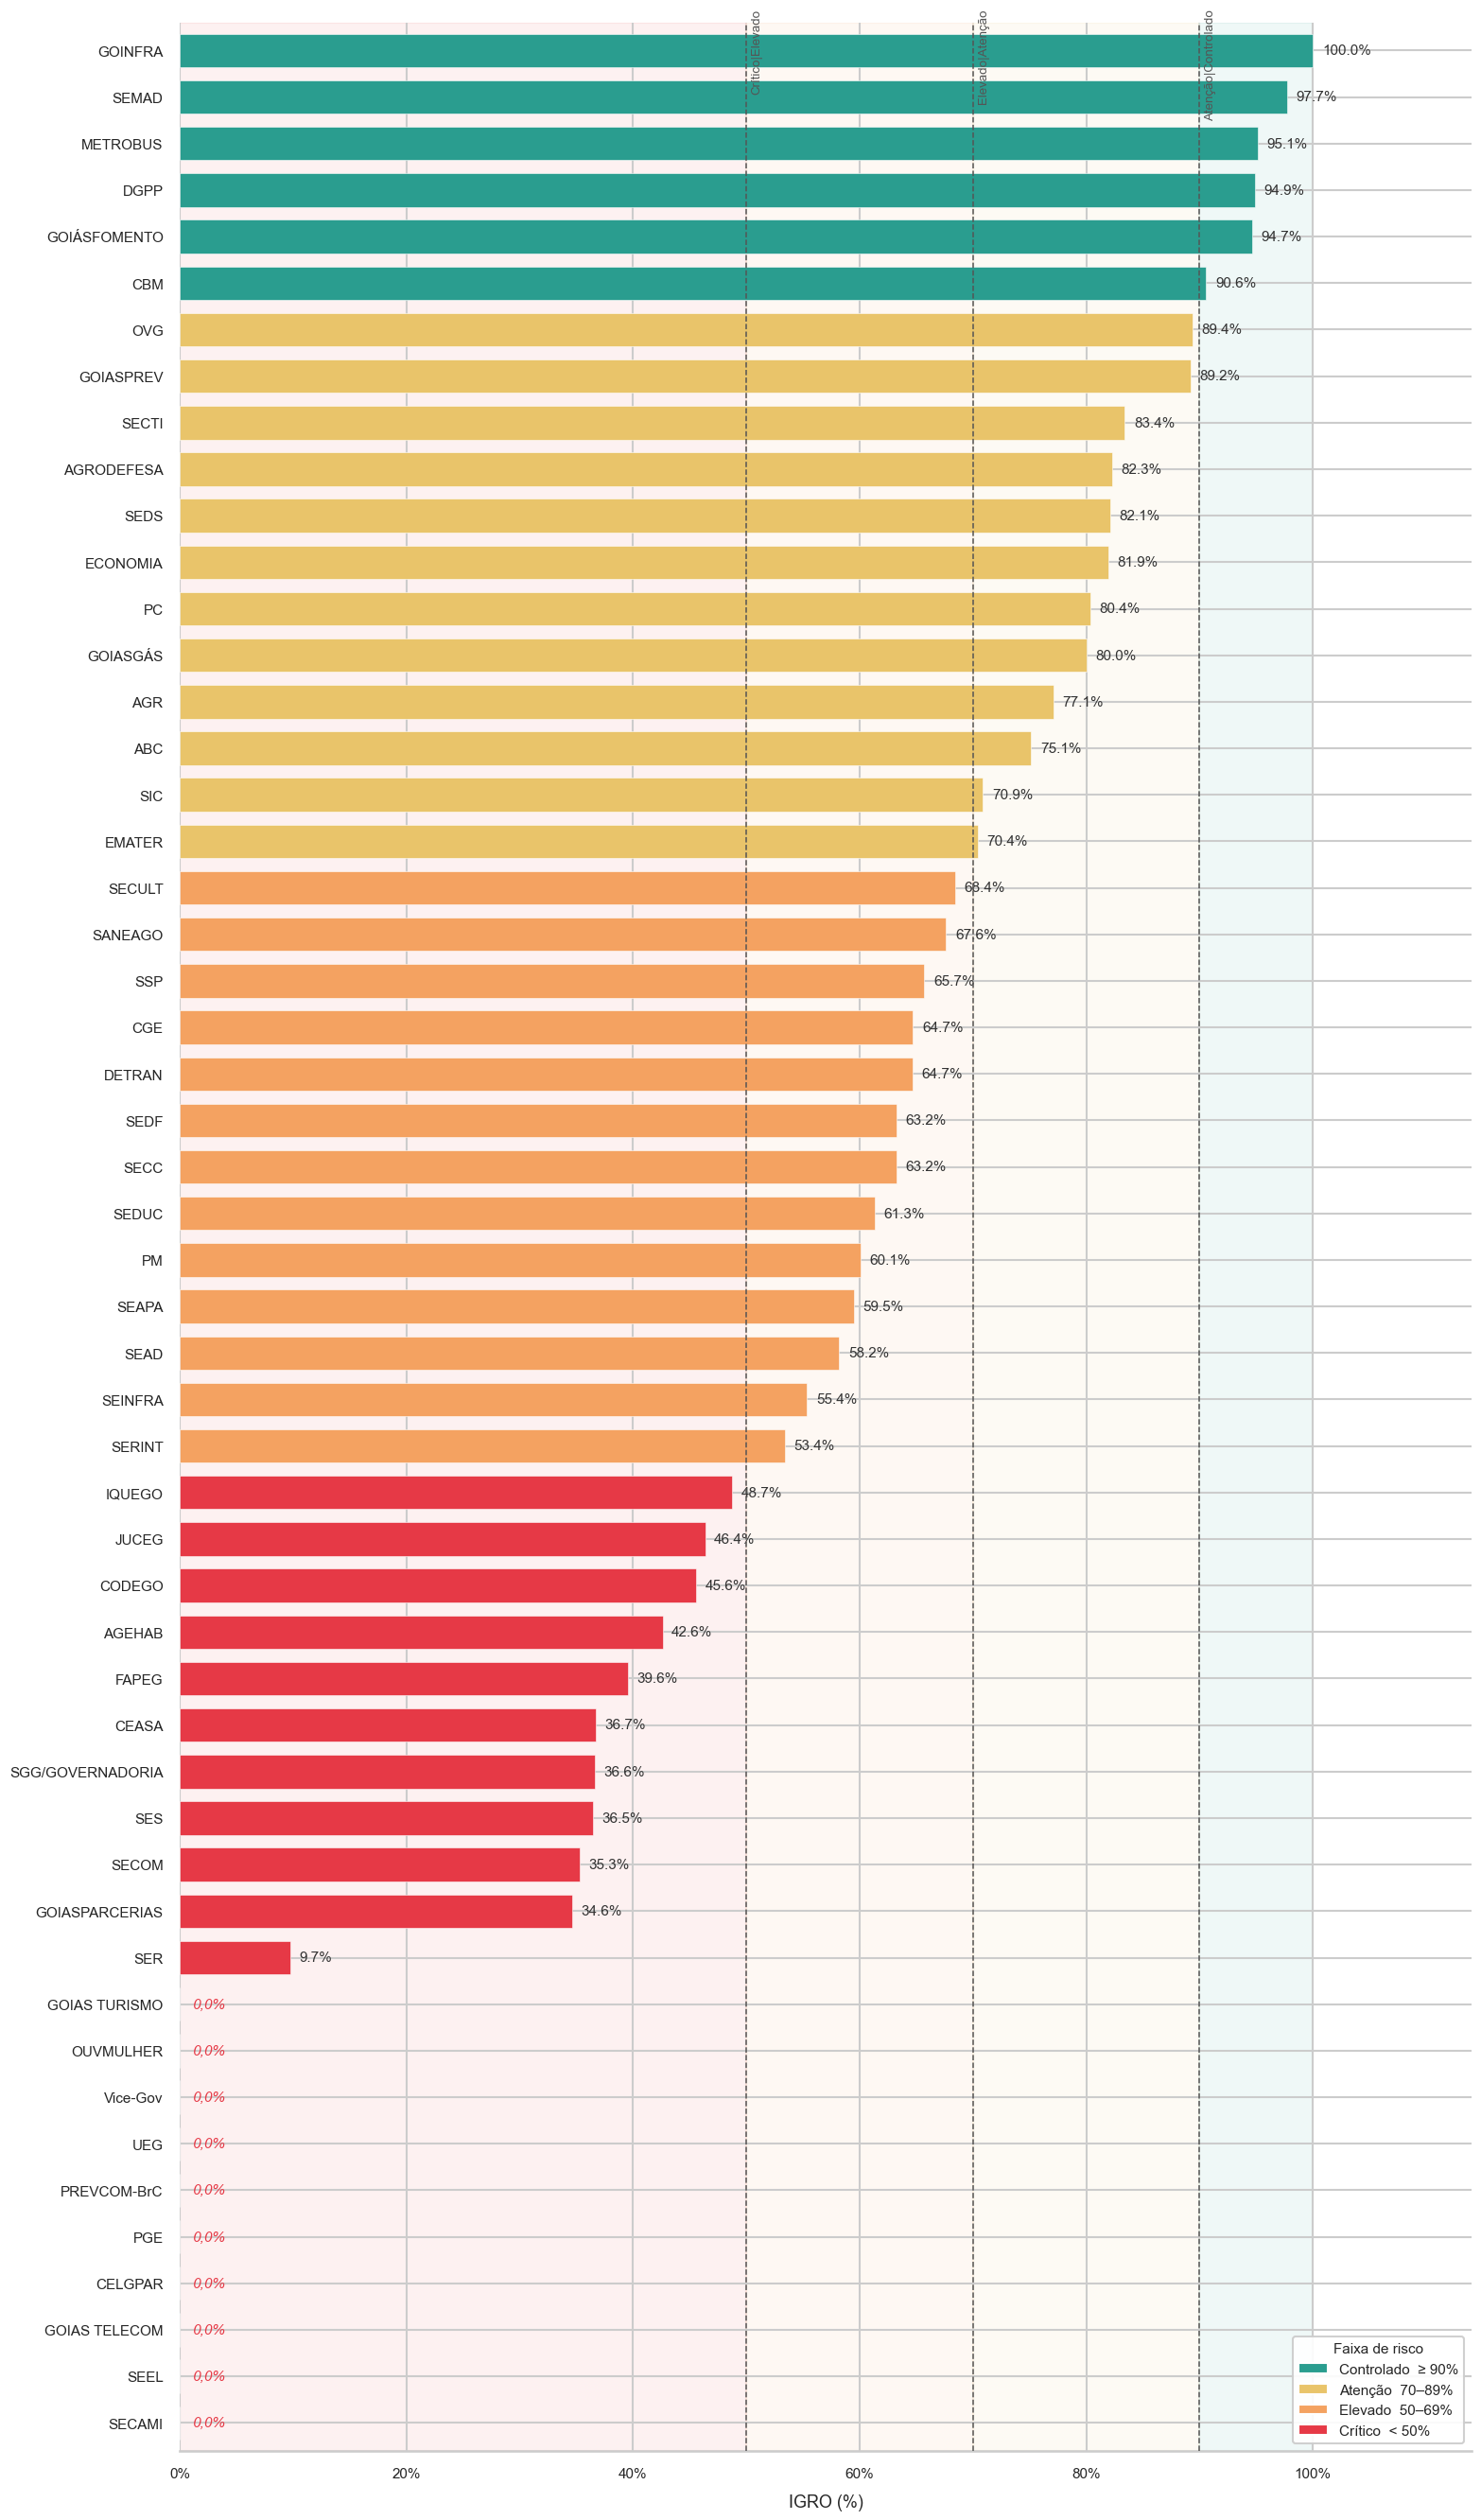

In [8]:
# Grafico 6 - Distribuicao do IGRO por orgao com faixas de risco
from matplotlib.patches import Patch

plot_df = df.sort_values("igro_pct", ascending=True).reset_index(drop=True)
n = len(plot_df)

palette = {
    "Controlado": "#2A9D8F",
    "Atencao":    "#E9C46A",
    "Elevado":    "#F4A261",
    "Critico":    "#E63946",
}

fig, ax = plt.subplots(figsize=(16, n * 0.48 + 2))

# Bandas de fundo por faixa de risco
for xmin, xmax, color in [(0, 50, "#E63946"), (50, 70, "#F4A261"), (70, 90, "#E9C46A"), (90, 100, "#2A9D8F")]:
    ax.axvspan(xmin, xmax, color=color, alpha=0.07, zorder=0)

# Barras
bar_colors = plot_df["faixa_risco"].map(palette)
ax.barh(
    range(n), plot_df["igro_pct"],
    color=bar_colors, edgecolor="white", linewidth=0.4, height=0.72, zorder=2
)

# Rotulos de valor no fim de cada barra
for i, (val, faixa) in enumerate(zip(plot_df["igro_pct"], plot_df["faixa_risco"])):
    if val > 0:
        ax.text(val + 0.8, i, f"{val:.1f}%", va="center", ha="left", fontsize=11, color="#333333")
    else:
        ax.text(1.2, i, "0,0%", va="center", ha="left", fontsize=11, color="#E63946", style="italic")

# Linhas de threshold com rotulos no topo
for val, rotulo in [(50, "Crítico|Elevado"), (70, "Elevado|Atenção"), (90, "Atenção|Controlado")]:
    ax.axvline(val, color="#555555", linestyle="--", linewidth=1.1, zorder=3)
    ax.text(val + 0.4, n - 0.1, rotulo, va="top", ha="left", fontsize=9.5,
            color="#555555", rotation=90, linespacing=1.4)

# Eixos
ax.set_yticks(range(n))
ax.set_yticklabels(plot_df["orgao"], fontsize=11)
ax.set_xlabel("IGRO (%)", fontsize=13, labelpad=10)
ax.set_xlim(0, 114)
ax.set_ylim(-0.6, n - 0.4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(left=False, labelsize=11)

# Legenda
legend_els = [
    Patch(facecolor=palette["Controlado"], label="Controlado  ≥ 90%"),
    Patch(facecolor=palette["Atencao"],    label="Atenção  70–89%"),
    Patch(facecolor=palette["Elevado"],    label="Elevado  50–69%"),
    Patch(facecolor=palette["Critico"],    label="Crítico  < 50%"),
]
ax.legend(handles=legend_els, loc="lower right", framealpha=0.92,
          fontsize=11, title="Faixa de risco", title_fontsize=11)

sns.despine(left=True, bottom=False)
fig.tight_layout()
save_fig(fig, "grafico_6_distribuicao_igro_por_orgao.png")
plt.show()

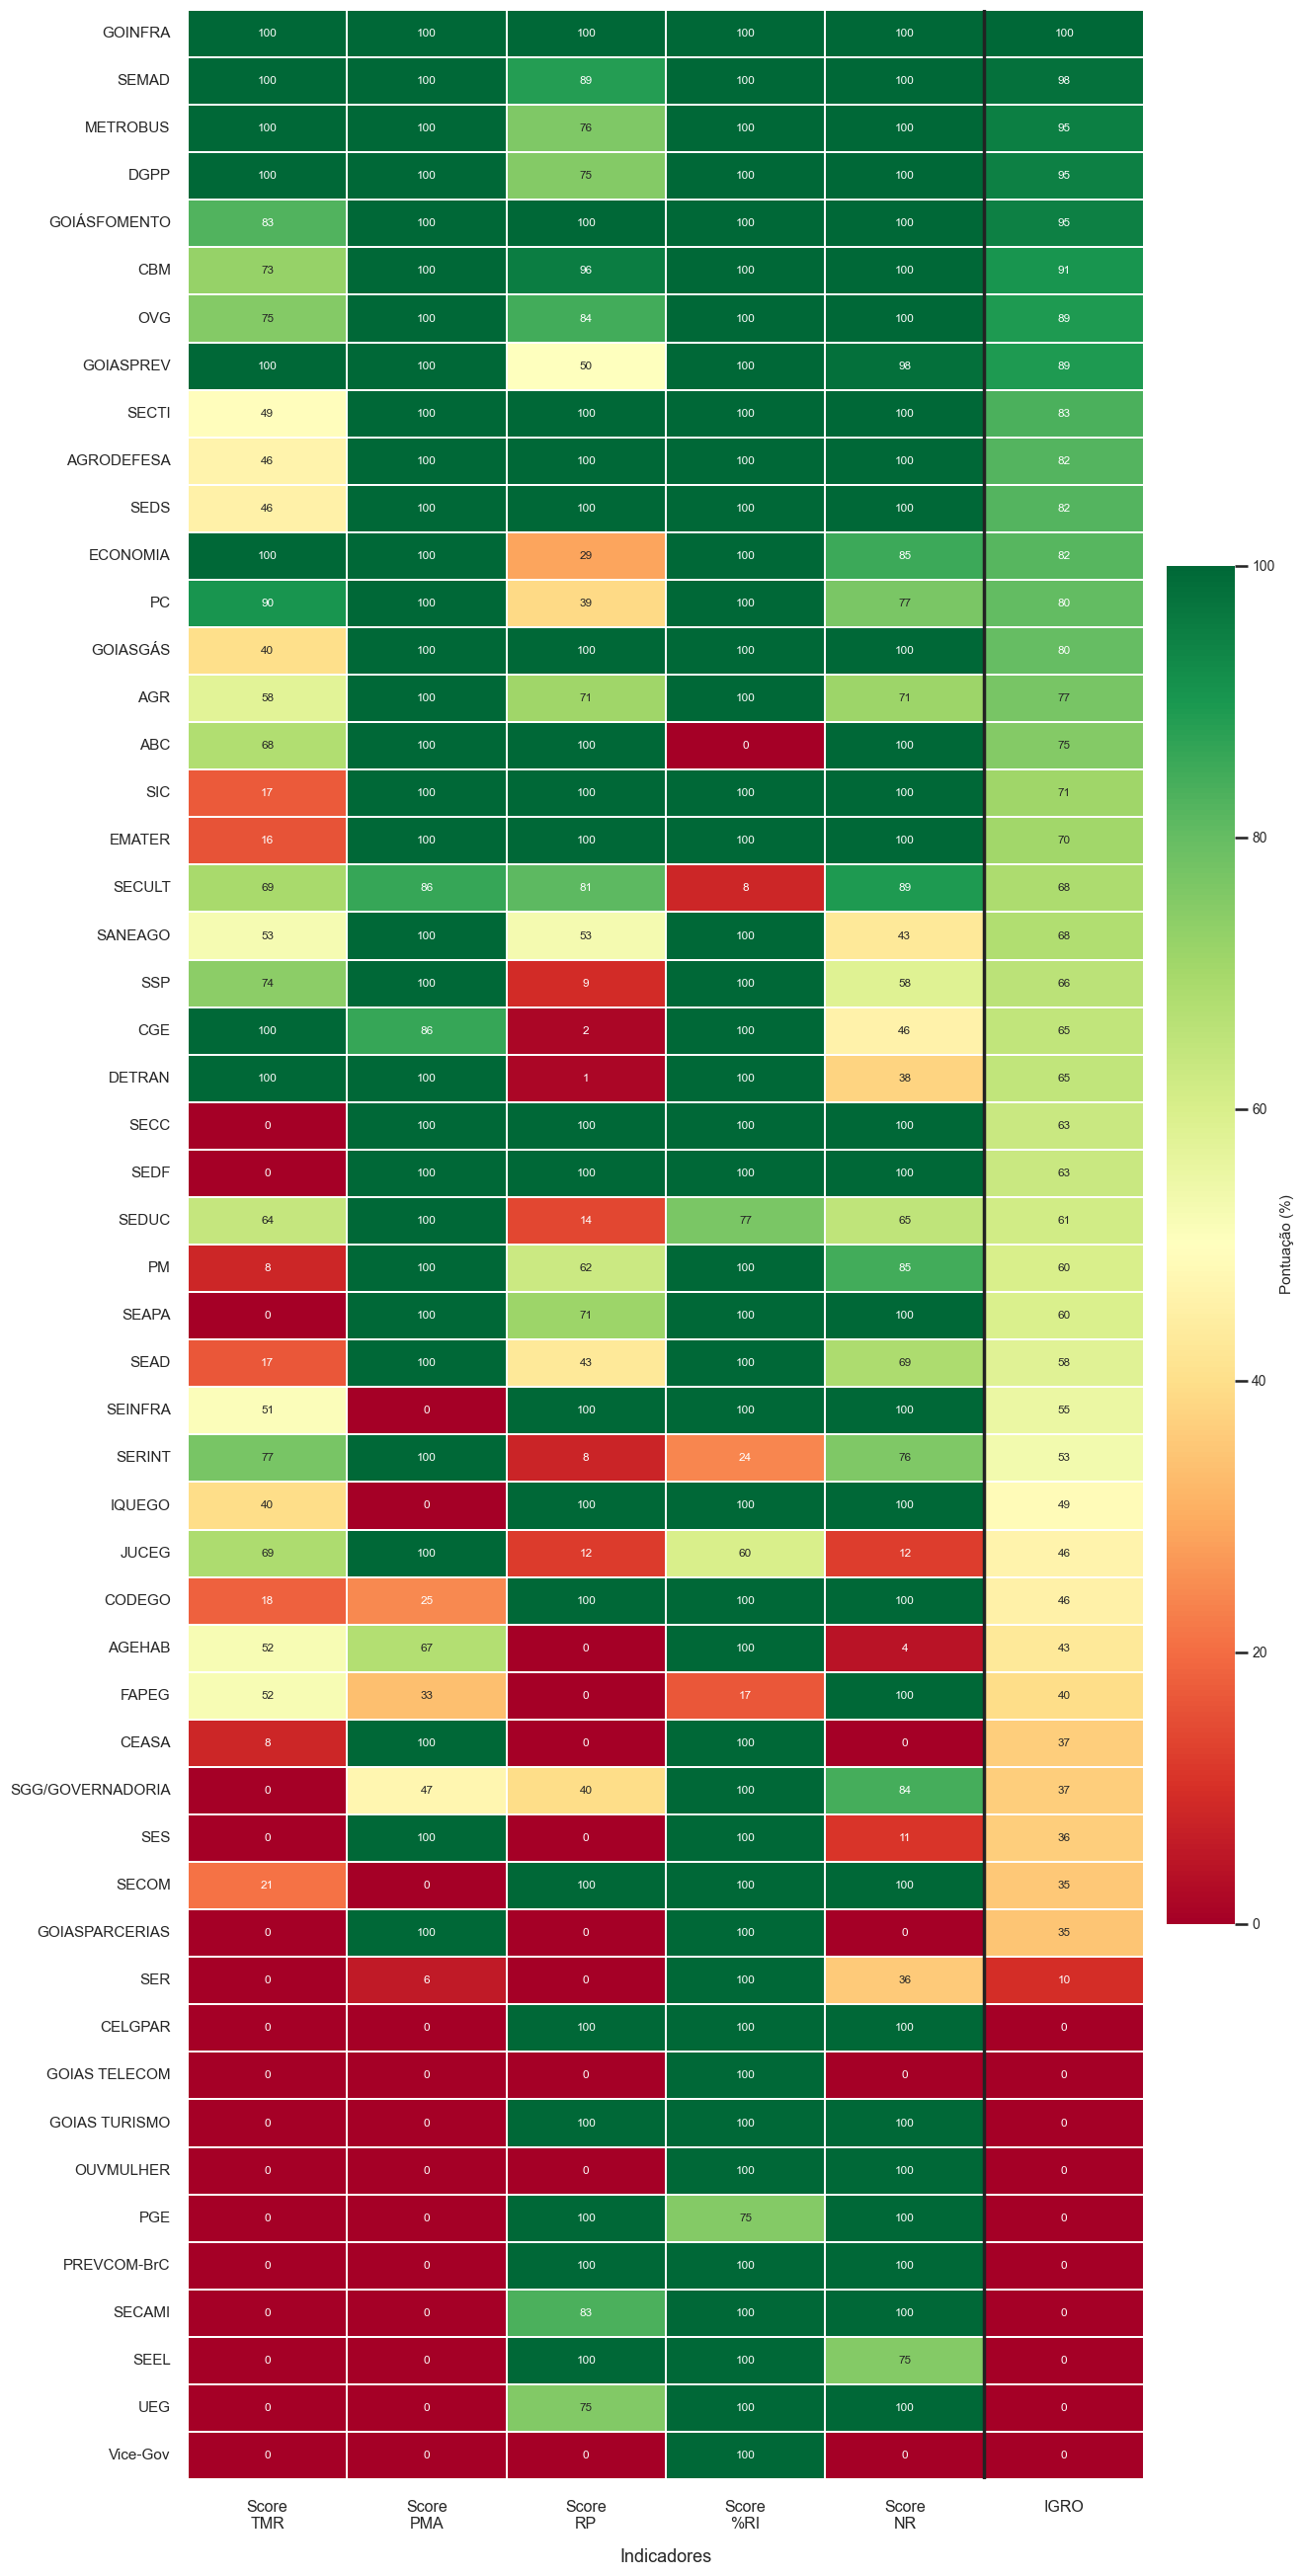

In [9]:
# Figura 4 - Heatmap dos KRIs e do IGRO por orgao
heatmap_cols = [
    "score_tmr_pct",
    "score_rdp_pct",
    "score_tr_pct",
    "score_ri_pct",
    "score_nr_pct",
    "igro_pct"
]
heatmap_df = df.set_index("orgao")[heatmap_cols].sort_values("igro_pct", ascending=False)
heatmap_df = heatmap_df.rename(columns={
    "score_tmr_pct": "Score\nTMR",
    "score_rdp_pct": "Score\nPMA",
    "score_tr_pct":  "Score\nRP",
    "score_ri_pct":  "Score\n%RI",
    "score_nr_pct":  "Score\nNR",
    "igro_pct":      "IGRO",
})

n = len(heatmap_df)
fig, ax = plt.subplots(figsize=(14, n * 0.46 + 2.5))

sns.heatmap(
    heatmap_df,
    cmap="RdYlGn",
    vmin=0, vmax=100,
    linewidths=0.35,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Pontuação (%)", "shrink": 0.55, "pad": 0.02},
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8.5},
)

# Separador visual entre os KRIs e o IGRO composto
ax.axvline(5, color="#222222", linewidth=2.5)

# Rotulos dos eixos
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11.5, rotation=0, ha="center", va="top")
ax.tick_params(axis="x", pad=6)
ax.set_xlabel("Indicadores", fontsize=13, labelpad=12)
ax.set_ylabel("")

# Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Pontuação (%)", fontsize=11)

fig.tight_layout()
save_fig(fig, "figura_4_heatmap_kri_por_orgao.png")
plt.show()

## 4. Tabelas auxiliares para a narrativa do artigo

Estas saidas ajudam a preencher a secao de casos extremos, checar top/bottom e apoiar a redacao da discussao.

In [10]:
colunas_quadro = [
    "orgao", "classe_operacional", "manifestacoes", "pesquisas", "tmr_dias", "pma_pct", "rp_pct", "ri_pct", "nr_nps", "igro_pct", "faixa_risco", "amostra_insuficiente"
]
top10 = df.nlargest(10, "igro_pct")[colunas_quadro]
bottom10 = df.nsmallest(10, "igro_pct")[colunas_quadro]
quadro_extremos = pd.concat([
    top10.assign(grupo="Top 10"),
    bottom10.assign(grupo="Bottom 10")
], ignore_index=True)
display(quadro_extremos)
save_table(quadro_extremos, "quadro_extremos_top_bottom_10.csv")

comparacao_extremos = pd.concat([
    df.nlargest(1, "igro_pct")[colunas_quadro].assign(perfil="Excelencia"),
    df.nsmallest(1, "igro_pct")[colunas_quadro].assign(perfil="Critico")
], ignore_index=True)
display(comparacao_extremos)
save_table(comparacao_extremos, "quadro_1_comparacao_extremos.csv")

,orgao,classe_operacional,manifestacoes,pesquisas,tmr_dias,pma_pct,rp_pct,ri_pct,nr_nps,igro_pct,faixa_risco,amostra_insuficiente,grupo
0,GOINFRA,3,2109,501,4.4600,0.0500,73.4500,1.7100,73.8500,100.0000,Controlado,False,Top 10
1,SEMAD,2,6126,429,3.2100,0.2400,67.7200,0.1100,67.6000,97.6900,Controlado,False,Top 10
2,METROBUS,4,190,23,3.7700,0.0000,65.2200,0.5300,39.1300,95.1000,Controlado,False,Top 10
3,DGPP,3,1089,60,4.1700,0.0000,65.0000,0.9200,56.6700,94.8700,Controlado,False,Top 10
4,GOIÁSFOMENTO,5,119,17,5.8700,0.0000,76.4700,1.6800,52.9400,94.6600,Controlado,False,Top 10
5,CBM,4,415,34,6.3700,0.0000,69.1200,0.9600,58.8200,90.5900,Controlado,False,Top 10
6,OVG,3,1240,74,6.2300,0.0000,66.8900,0.8100,52.7000,89.4000,Atencao,False,Top 10
7,GOIASPREV,4,753,134,4.9900,0.1300,60.0700,1.2000,44.0300,89.2100,Atencao,False,Top 10
8,SECTI,4,308,29,7.5400,0.3200,75.8600,1.9500,68.9700,83.4100,Atencao,False,Top 10
9,AGRODEFESA,4,242,18,7.6900,0.4100,77.7800,0.8300,66.6700,82.2900,Atencao,False,Top 10


,orgao,classe_operacional,manifestacoes,pesquisas,tmr_dias,pma_pct,rp_pct,ri_pct,nr_nps,igro_pct,faixa_risco,amostra_insuficiente,perfil
0,GOINFRA,3,2109,501,4.4600,0.0500,73.4500,1.7100,73.8500,100.0000,Controlado,False,Excelencia
1,CELGPAR,5,4,1,18.7500,50.0000,100.0000,0.0000,100.0000,0.0000,Critico,False,Critico


## 5. Analises extras recomendadas

Aqui entram sugestoes que nao aparecem de forma explicita na lista do artigo, mas tendem a melhorar a robustez da narrativa e a transparencia metodologica.

,orgao,uniforme_geometrico,tempestividade_pesada,qualidade_pesada,aritmetico_uniforme,rank_uniforme_geometrico,rank_tempestividade_pesada,rank_qualidade_pesada,rank_aritmetico_uniforme
0,GOINFRA,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,SEMAD,0.9760,0.9840,0.9708,0.9772,2.0000,2.0000,3.0000,2.0000
4,GOIÁSFOMENTO,0.9627,0.9446,0.9750,0.9654,3.0000,5.0000,2.0000,3.0000
2,METROBUS,0.9468,0.9642,0.9354,0.9522,4.0000,3.0000,5.0000,4.0000
3,DGPP,0.9441,0.9624,0.9321,0.9500,5.0000,4.0000,6.0000,5.0000
5,CBM,0.9295,0.9029,0.9477,0.9363,6.0000,7.0000,4.0000,6.0000
6,OVG,0.9136,0.8981,0.9240,0.9196,7.0000,8.0000,7.0000,7.0000
7,GOIASPREV,0.8685,0.9103,0.8417,0.8970,8.0000,6.0000,12.0000,9.0000
8,SECTI,0.8681,0.8088,0.9100,0.8986,9.0000,11.0000,8.0000,8.0000
9,AGRODEFESA,0.8569,0.7932,0.9022,0.8924,10.0000,12.0000,9.0000,10.0000


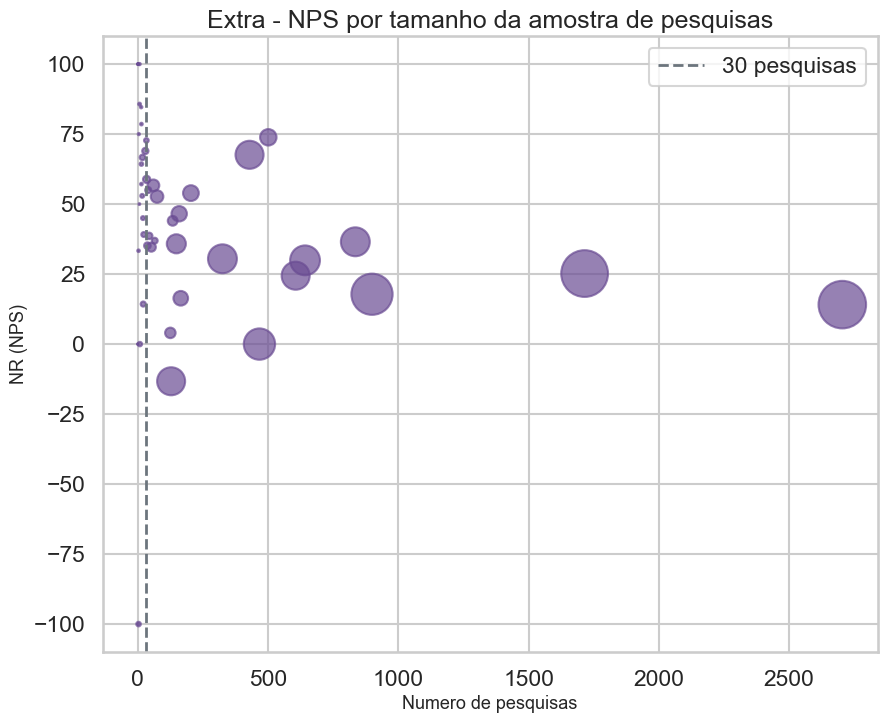

In [11]:
# Extra A - sensibilidade de ranking com cenarios de ponderacao
def geometric_weighted_mean(frame: pd.DataFrame, columns: list[str], weights: list[float]) -> pd.Series:
    weights = np.array(weights, dtype=float)
    weights = weights / weights.sum()
    safe = frame[columns].clip(lower=1e-6)
    return np.exp(np.log(safe).mul(weights, axis=1).sum(axis=1))

score_base_cols = ["score_tmr", "score_rdp", "score_tr", "score_ri", "score_nr"]
cenarios = {
    "uniforme_geometrico": [0.2, 0.2, 0.2, 0.2, 0.2],
    "tempestividade_pesada": [0.3, 0.3, 0.1333, 0.1333, 0.1334],
    "qualidade_pesada": [0.1333, 0.1333, 0.2445, 0.2445, 0.2444]
}

sens = df[["orgao", *score_base_cols]].copy()
for nome, pesos in cenarios.items():
    sens[nome] = geometric_weighted_mean(sens, score_base_cols, pesos)

sens["aritmetico_uniforme"] = sens[score_base_cols].mean(axis=1)

ranking_cols = ["uniforme_geometrico", "tempestividade_pesada", "qualidade_pesada", "aritmetico_uniforme"]
for col in ranking_cols:
    sens[f"rank_{col}"] = sens[col].rank(method="min", ascending=False)

display(sens[["orgao", *ranking_cols, *(f"rank_{c}" for c in ranking_cols)]].sort_values("rank_uniforme_geometrico").head(15))
save_table(sens[["orgao", *ranking_cols, *(f"rank_{c}" for c in ranking_cols)]], "sensibilidade_cenarios_ranking.csv")

if spearmanr is not None:
    base_rank = sens["rank_uniforme_geometrico"]
    corr_rows = []
    for col in ["rank_tempestividade_pesada", "rank_qualidade_pesada", "rank_aritmetico_uniforme"]:
        coef, p_value = spearmanr(base_rank, sens[col])
        corr_rows.append({"cenario": col, "spearman": coef, "p_valor": p_value})
    display(pd.DataFrame(corr_rows))

# Extra B - confiabilidade da parte perceptiva versus tamanho amostral
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df["pesquisas"], df["nr_nps"], s=np.maximum(df["manifestacoes"], 10) / 15, alpha=0.7, color="#6A4C93")
ax.axvline(30, color="#6C757D", linestyle="--", linewidth=2, label="30 pesquisas")
ax.set_title("Extra - NPS por tamanho da amostra de pesquisas")
ax.set_xlabel("Numero de pesquisas")
ax.set_ylabel("NR (NPS)")
ax.legend()
save_fig(fig, "extra_nps_vs_tamanho_amostra.png")
plt.show()

## 6. Proximos passos sugeridos

Sugestoes de uso depois de rodar o notebook:
- decidir se o artigo vai trabalhar com `51` ou `52` orgaos e documentar a regra de exclusao, se houver;
- revisar se `rdp` realmente corresponde ao conceito editorial de `PMA` antes da versao final;
- aproveitar a secao de sensibilidade para preencher a subsecao 4.6 do artigo;
- usar as tabelas exportadas em `09_resultados/artigo_igro_figuras_tabelas/` como base para quadros e anexos;
- considerar um grafico extra de confiabilidade por amostra quando for discutir limitacoes dos indicadores perceptivos.